# Análisis de Tráfico de Red con Data Science

**Práctica:** Monitoreo, captura y análisis de tráfico Wi-Fi  
**Herramienta de captura:** NetworkMonitor v2.5 (Java + Pcap4J + SNI)

---

## Contenido
1. Carga y limpieza de datos (soporta 1, 2 o 3 CSV)
2. Análisis Exploratorio
3. Grafica 1 — TCP vs UDP
4. Grafica 2 — Dispersion Tamano vs Tiempo
5. Grafica 3 — Puertos mas usados
6. **Modelo 1 — Analisis de Tendencias (Trafico por Hora)**
7. **Modelo 2 — Clasificacion KNN**
8. **Modelo 3 — Clustering K-Means**
9. Grafica 9 — Top Sitios / Apps mas visitados
10. Resumen y Conclusiones

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os, importlib
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

print('Librerias cargadas correctamente.')

Failed to read module file 'C:\Users\RICARDO\AppData\Local\Programs\Python\Python312\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\RICARDO\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\RICARDO\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\RICARDO\AppData\Local\Programs\Python\Python312\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_loa

Librerias cargadas correctamente.


---
## Seccion 1 — Carga y Limpieza de Datos

El sistema detecta automaticamente los CSV disponibles: uno, dos o los tres dias.

In [ ]:
import importlib, limpieza_datos, visualizacion, modelos
importlib.reload(limpieza_datos)
importlib.reload(visualizacion)
importlib.reload(modelos)
from limpieza_datos import cargar_datos

df = cargar_datos(verbose=True)
print(f"\nDataset listo: {len(df):,} registros")

In [3]:
# Primeras filas del dataset
df.head(8)

,ip_origen,ip_destino,mac_origen,mac_destino,puerto_origen,puerto_destino,protocolo,longitud,hora_captura,dispositivo_local,...,hora,servicio,rango_puerto_dst,rango_puerto_src,app_inferida,protocolo_enc,servicio_enc,longitud_scaled,po_scaled,pd_scaled
0,172.16.76.180,104.18.19.125,d4:d8:53:5d:25:cd,88:15:44:a7:ba:6c,53612,443,TCP,54,2026-03-04 17:14:30,Equipo-76.180,...,17,HTTPS,Conocido,Dinamico,Cloudflare/ChatGPT-posible,0,4,-0.337439,0.981620,-0.742893
1,172.16.76.180,99.83.165.34,d4:d8:53:5d:25:cd,88:15:44:a7:ba:6c,55549,443,TCP,93,2026-03-04 17:14:30,Equipo-76.180,...,17,HTTPS,Conocido,Dinamico,Otro,0,4,-0.274881,1.051352,-0.742893
2,99.83.165.34,172.16.76.180,88:15:44:a7:ba:6c,d4:d8:53:5d:25:cd,443,55549,TCP,60,2026-03-04 17:14:30,Equipo-76.180,...,17,Dinamico-privado,Dinamico,Conocido,Otro,0,2,-0.327815,-0.932471,1.360296
3,172.16.81.149,172.16.95.255,e4:fd:45:2e:dd:df,ff:ff:ff:ff:ff:ff,137,137,UDP,92,2026-03-04 17:14:30,Equipo-81.149,...,17,Sistema-conocido,Conocido,Conocido,Otro,1,7,-0.276485,-0.943487,-0.754572
4,99.83.165.34,172.16.76.180,88:15:44:a7:ba:6c,d4:d8:53:5d:25:cd,443,55549,TCP,93,2026-03-04 17:14:30,Equipo-76.180,...,17,Dinamico-privado,Dinamico,Conocido,Otro,0,2,-0.274881,-0.932471,1.360296
5,172.16.76.180,99.83.165.34,d4:d8:53:5d:25:cd,88:15:44:a7:ba:6c,55549,443,TCP,54,2026-03-04 17:14:30,Equipo-76.180,...,17,HTTPS,Conocido,Dinamico,Otro,0,4,-0.337439,1.051352,-0.742893
6,172.16.76.180,44.215.215.40,d4:d8:53:5d:25:cd,88:15:44:a7:ba:6c,55554,443,TCP,55,2026-03-04 17:14:30,Equipo-76.180,...,17,HTTPS,Conocido,Dinamico,AWS,0,4,-0.335835,1.051532,-0.742893
7,44.215.215.40,172.16.76.180,88:15:44:a7:ba:6c,d4:d8:53:5d:25:cd,443,55554,TCP,66,2026-03-04 17:14:30,Equipo-76.180,...,17,Dinamico-privado,Dinamico,Conocido,Otro,0,2,-0.318191,-0.932471,1.360486


In [4]:
# Estadisticas descriptivas de variables numericas
df[['longitud', 'puerto_origen', 'puerto_destino', 'hora']].describe().round(2)

,longitud,puerto_origen,puerto_destino,hora
count,58641.00,58641.0,58641.0,58641.0
mean,264.37,26344.87,19907.66,17.0
std,623.43,27777.92,26201.39,0.0
min,54.00,53.0,53.0,17.0
25%,66.00,443.0,443.0,17.0
50%,100.00,5353.0,5353.0,17.0
75%,220.00,56753.0,53356.0,17.0
max,45999.00,65534.0,65534.0,17.0


---
## Seccion 2 — Analisis Exploratorio

In [5]:
print('=== Distribucion de protocolos ===')
conteo_proto = df['protocolo'].value_counts()
print(conteo_proto.to_string())
tcp_p = conteo_proto.get('TCP', 0) / len(df) * 100
udp_p = conteo_proto.get('UDP', 0) / len(df) * 100
print(f'\nPorcentaje TCP: {tcp_p:.1f}%')
print(f'Porcentaje UDP: {udp_p:.1f}%')

=== Distribucion de protocolos ===
protocolo
TCP    37035
UDP    21606

Porcentaje TCP: 63.2%
Porcentaje UDP: 36.8%


In [6]:
print('=== Top 10 puertos destino mas usados ===')
print(df['puerto_destino'].value_counts().head(10).to_string())

=== Top 10 puertos destino mas usados ===
puerto_destino
443      15094
5353     13894
80        5597
53        1778
64561     1472
1900       907
67         855
137        779
53612      692
5355       584


In [7]:
print('=== Dispositivos mas activos en la red ===')
col_disp = 'dispositivo_local' if 'dispositivo_local' in df.columns else 'ip_origen'
activos = df.groupby(col_disp).agg(
    paquetes=('longitud', 'count'),
    bytes_total=('longitud', 'sum')
).sort_values('paquetes', ascending=False)
print(activos.head(15).to_string())

=== Dispositivos mas activos en la red ===
                   paquetes  bytes_total
dispositivo_local                       
Equipo-76.180         40655     12161009
Axel                    919       392493
Android                 841       177702
Equipo-128.128          602        49872
Equipo-78.30            525        46073
Equipo-2.142            315        82029
Equipo-75.179           293        27256
Equipo-77.183           289        34303
Android-70              215        91734
Android-4               192        50283
Equipo-76.74            189        17449
Android-25              173        44374
Equipo-81.221           169        24614
DESKTOP-A4RFFQO         158        14415
Equipo-74.190           148        16477


---
## Grafica 1 — Distribucion TCP vs UDP

  Grafica guardada: C:\Users\RICARDO\Documents\NetBeansProjects\NetworkMonitor\analisis_python\resultados\01_tcp_vs_udp.png


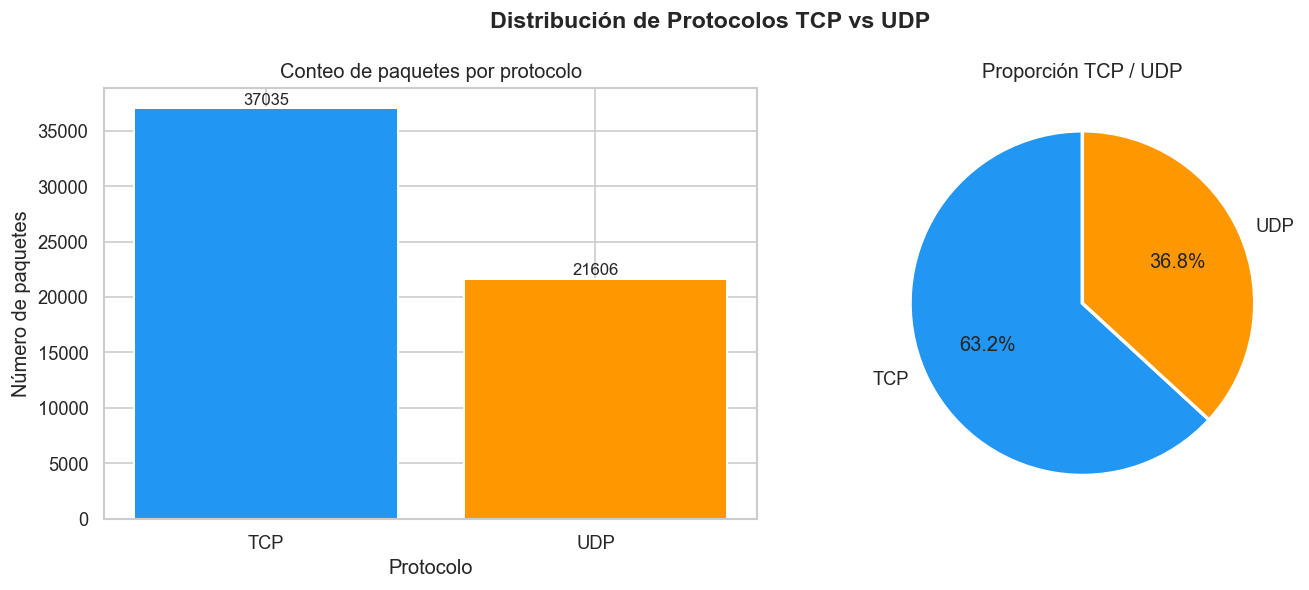

  ANALISIS — DISTRIBUCION TCP vs UDP
  TCP: 37,035 paquetes (63.2%)
  UDP: 21,606 paquetes (36.8%)

  Conclusion: Predomina TCP, indicando actividad de navegacion web (HTTPS),
  transferencia de archivos y uso de aplicaciones que requieren conexion estable.
  Puerto 443 (HTTPS) es el mas comun en redes educativas actualest.
  Puerto 53 (DNS) aparece en UDP para resoluciones de dominio.


In [8]:
from visualizacion import grafica_tcp_udp
grafica_tcp_udp(df)
plt.show()

conteo = df['protocolo'].value_counts()
tcp_p  = conteo.get('TCP', 0) / len(df) * 100
udp_p  = conteo.get('UDP', 0) / len(df) * 100
print('=' * 70)
print('  ANALISIS — DISTRIBUCION TCP vs UDP')
print('=' * 70)
print(f'  TCP: {conteo.get("TCP",0):,} paquetes ({tcp_p:.1f}%)')
print(f'  UDP: {conteo.get("UDP",0):,} paquetes ({udp_p:.1f}%)')
print()
if tcp_p > 60:
    print('  Conclusion: Predomina TCP, indicando actividad de navegacion web (HTTPS),')
    print('  transferencia de archivos y uso de aplicaciones que requieren conexion estable.')
else:
    print('  Conclusion: Hay un alto volumen de UDP, tipico de streaming, consultas DNS')
    print('  y comunicaciones en tiempo real como videollamadas o juegos en linea.')
print('  Puerto 443 (HTTPS) es el mas comun en redes educativas actualest.')
print('  Puerto 53 (DNS) aparece en UDP para resoluciones de dominio.')
print('=' * 70)

---
## Grafica 2 — Dispersion Tamano de Paquetes vs Tiempo

  Grafica guardada: C:\Users\RICARDO\Documents\NetBeansProjects\NetworkMonitor\analisis_python\resultados\02_dispersion_tamano_hora.png


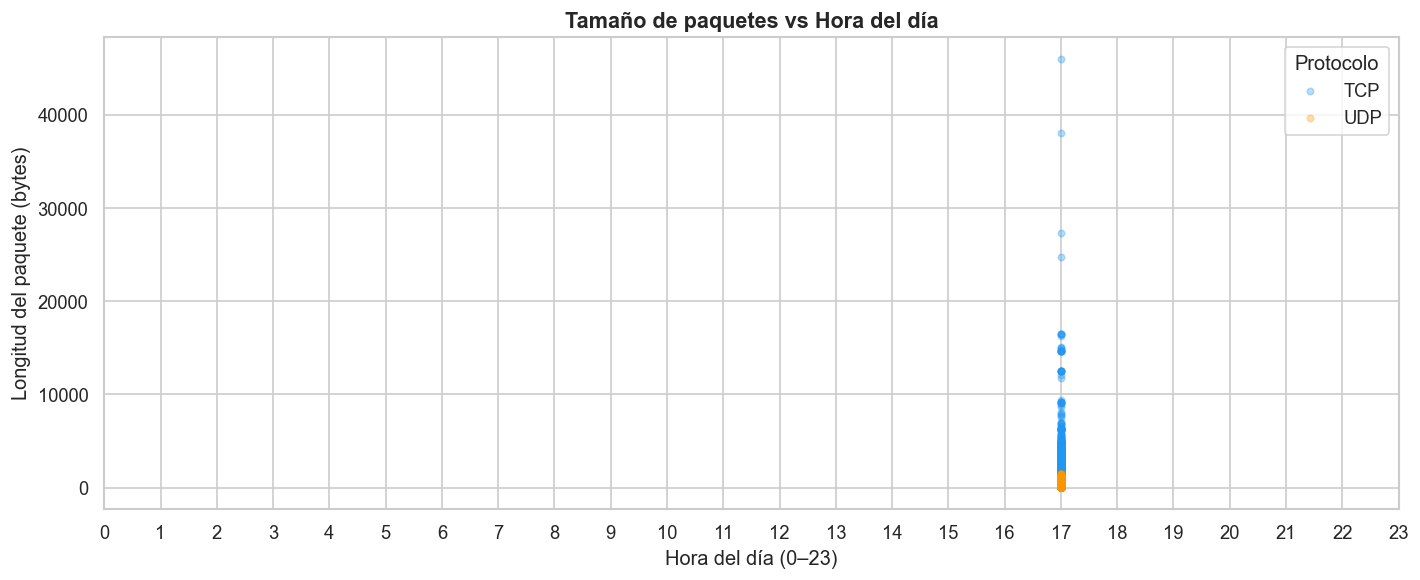

  ANALISIS — DISPERSION TAMANO DE PAQUETES
  Tamano promedio de paquete : 264 bytes
  Tamano maximo              : 45,999 bytes

  Conclusion: Paquetes pequeños (<200 bytes) son tipicos de trafico
  de control (ACKs, DNS, handshakes). Paquetes grandes (>1000 bytes)
  corresponden a transferencias de datos como paginas web o descargas.
  La distribucion ayuda a identificar anomalias en el tamano de paquetes.


In [9]:
from visualizacion import grafica_dispersion_tamano_hora
grafica_dispersion_tamano_hora(df)
plt.show()

pq_prom = df['longitud'].mean()
pq_max  = df['longitud'].max()
print('=' * 70)
print('  ANALISIS — DISPERSION TAMANO DE PAQUETES')
print('=' * 70)
print(f'  Tamano promedio de paquete : {pq_prom:.0f} bytes')
print(f'  Tamano maximo              : {pq_max:,} bytes')
print()
print('  Conclusion: Paquetes pequeños (<200 bytes) son tipicos de trafico')
print('  de control (ACKs, DNS, handshakes). Paquetes grandes (>1000 bytes)')
print('  corresponden a transferencias de datos como paginas web o descargas.')
print('  La distribucion ayuda a identificar anomalias en el tamano de paquetes.')
print('=' * 70)

---
## Grafica 3 — Puertos mas Utilizados

  Grafica guardada: C:\Users\RICARDO\Documents\NetBeansProjects\NetworkMonitor\analisis_python\resultados\03_puertos_frecuentes.png


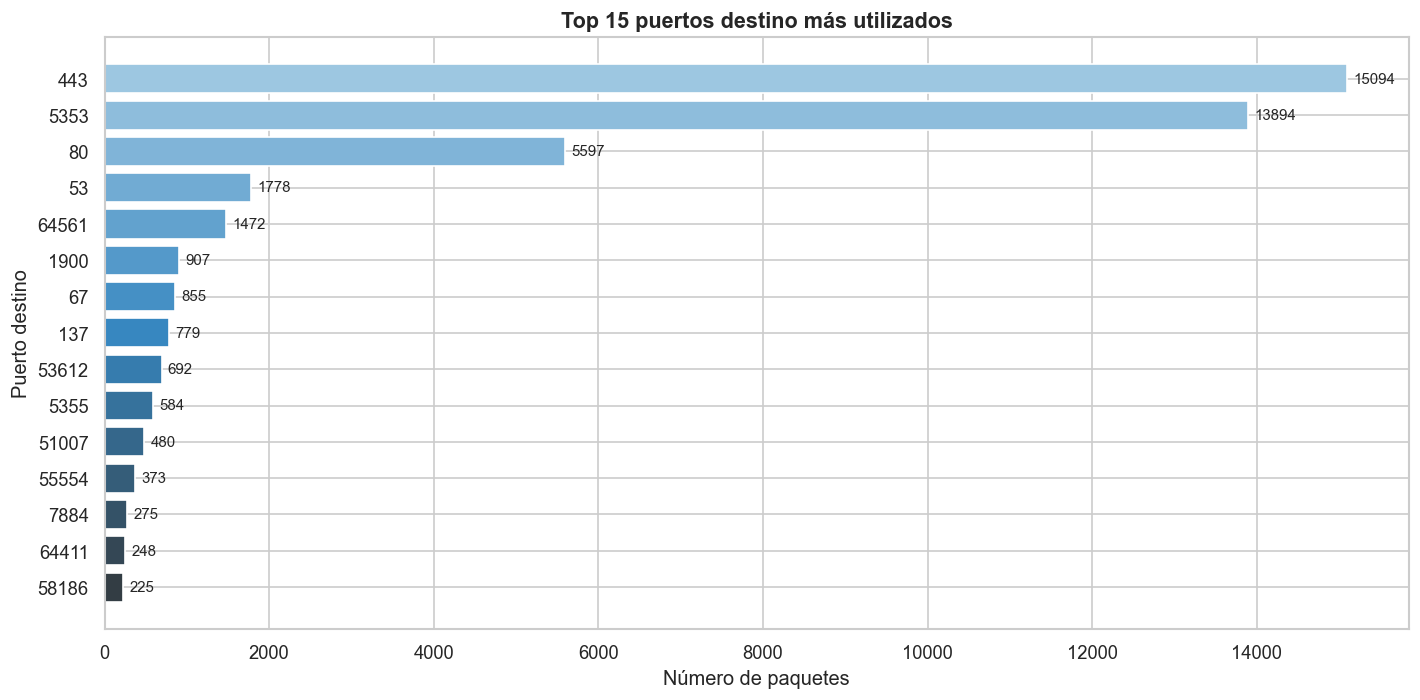

  ANALISIS — PUERTOS MAS UTILIZADOS
  Puerto 443    :   15,094 paquetes  — HTTPS (navegacion segura)
  Puerto 5353   :   13,894 paquetes  — mDNS (descubrimiento local)
  Puerto 80     :    5,597 paquetes  — HTTP (navegacion sin cifrado)
  Puerto 53     :    1,778 paquetes  — DNS (resolucion de nombres)
  Puerto 64561  :    1,472 paquetes  — Servicio no estandar / aplicacion

  Conclusion: Los puertos muestran los servicios mas usados por los
  estudiantes. Si el 443 domina, confirma navegacion HTTPS. Si el 53
  es alto, hay muchas resoluciones DNS activas (multiples dispositivos
  reconectandose o aplicaciones consultando dominios continuamente).


In [10]:
from visualizacion import grafica_puertos_frecuentes
grafica_puertos_frecuentes(df)
plt.show()

top_puertos = df['puerto_destino'].value_counts().head(5)
print('=' * 70)
print('  ANALISIS — PUERTOS MAS UTILIZADOS')
print('=' * 70)
PUERTOS_CONOCIDOS = {
    443: 'HTTPS (navegacion segura)',
    80:  'HTTP (navegacion sin cifrado)',
    53:  'DNS (resolucion de nombres)',
    8080:'HTTP alternativo',
    22:  'SSH (acceso remoto)',
    25:  'SMTP (correo)',
    993: 'IMAPS (correo cifrado)',
    5353:'mDNS (descubrimiento local)',
}
for p, cnt in top_puertos.items():
    desc = PUERTOS_CONOCIDOS.get(int(p), 'Servicio no estandar / aplicacion')
    print(f'  Puerto {int(p):<6} : {cnt:>8,} paquetes  — {desc}')
print()
print('  Conclusion: Los puertos muestran los servicios mas usados por los')
print('  estudiantes. Si el 443 domina, confirma navegacion HTTPS. Si el 53')
print('  es alto, hay muchas resoluciones DNS activas (multiples dispositivos')
print('  reconectandose o aplicaciones consultando dominios continuamente).')
print('=' * 70)

---
## Modelo 1 — Analisis de Tendencias (Trafico por Hora)

**Objetivo:** Predecir el protocolo predominante (TCP/UDP) según la hora del dia.  
**Metodo:** Regresion logistica entrenada con los patrones de hora y tamano de paquete.  
**Uso practico:** Identificar horas pico, optimizar QoS y detectar uso indebido fuera de horario academico.

In [11]:
from modelos import predecir_protocolo_por_hora
from visualizacion import grafica_trafico_por_hora, grafica_prediccion_hora

res_pred = predecir_protocolo_por_hora(df)

  ANÁLISIS PREDICTIVO  (Regresión Logística)
  Accuracy : 0.6325 (63.25%)

              precision    recall  f1-score   support

         UDP       0.63      1.00      0.77      7419
         TCP       0.00      0.00      0.00      4310

    accuracy                           0.63     11729
   macro avg       0.32      0.50      0.39     11729
weighted avg       0.40      0.63      0.49     11729


  Predicción de protocolo por hora del día:
 hora protocolo_pred  prob_tcp  prob_udp
    0            UDP  0.499515  0.500485
    1            UDP  0.491273  0.508727
    2            UDP  0.483035  0.516965
    3            UDP  0.474807  0.525193
    4            UDP  0.466592  0.533408
    5            UDP  0.458396  0.541604
    6            UDP  0.450222  0.549778
    7            UDP  0.442075  0.557925
    8            UDP  0.433958  0.566042
    9            UDP  0.425877  0.574123
   10            UDP  0.417836  0.582164
   11            UDP  0.409838  0.590162
   12            UDP

Failed to read module file 'C:\Users\RICARDO\Documents\NetBeansProjects\NetworkMonitor\analisis_python\modelos.py' for module 'modelos': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\RICARDO\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 219, in update_sources
    self.source_by_modname[new_modname] = f.read()
                                          ^^^^^^^^
  File "C:\Users\RICARDO\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x81 in position 6515: character maps to <undefined>


  Grafica guardada: C:\Users\RICARDO\Documents\NetBeansProjects\NetworkMonitor\analisis_python\resultados\05_trafico_por_hora.png


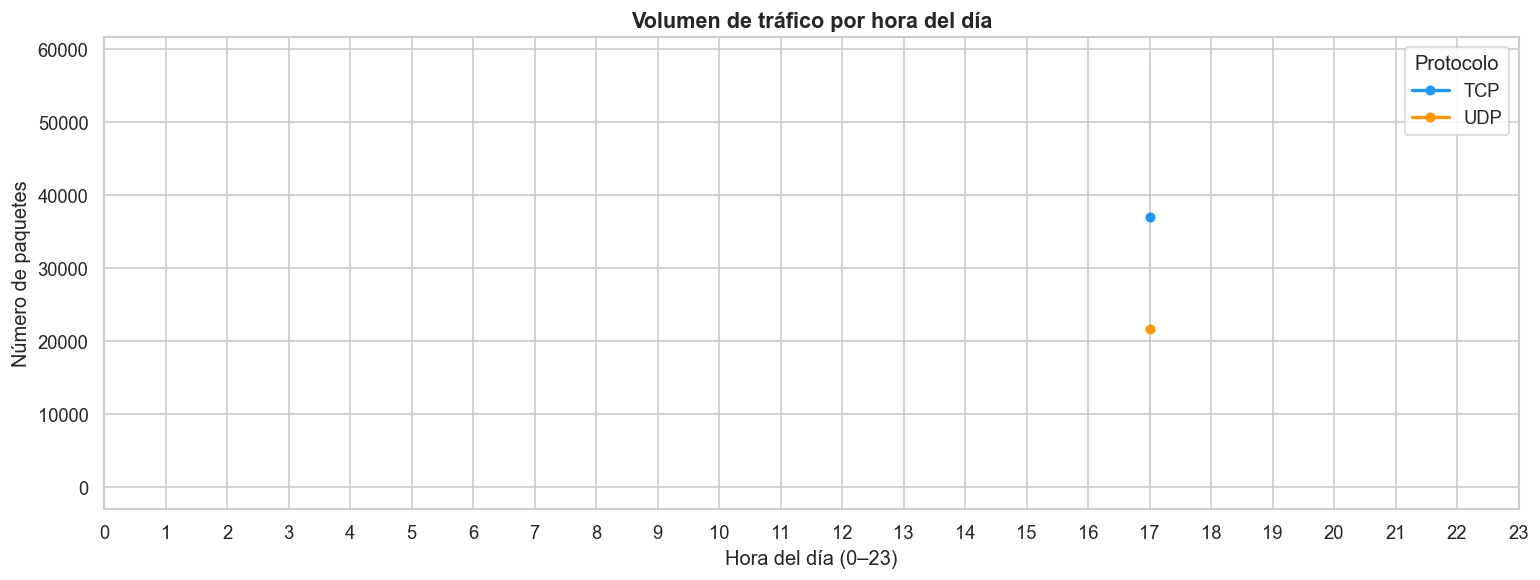

In [12]:
# Grafica 5: Trafico real por hora
grafica_trafico_por_hora(df)
plt.show()

  Grafica guardada: C:\Users\RICARDO\Documents\NetBeansProjects\NetworkMonitor\analisis_python\resultados\07_prediccion_protocolo_hora.png


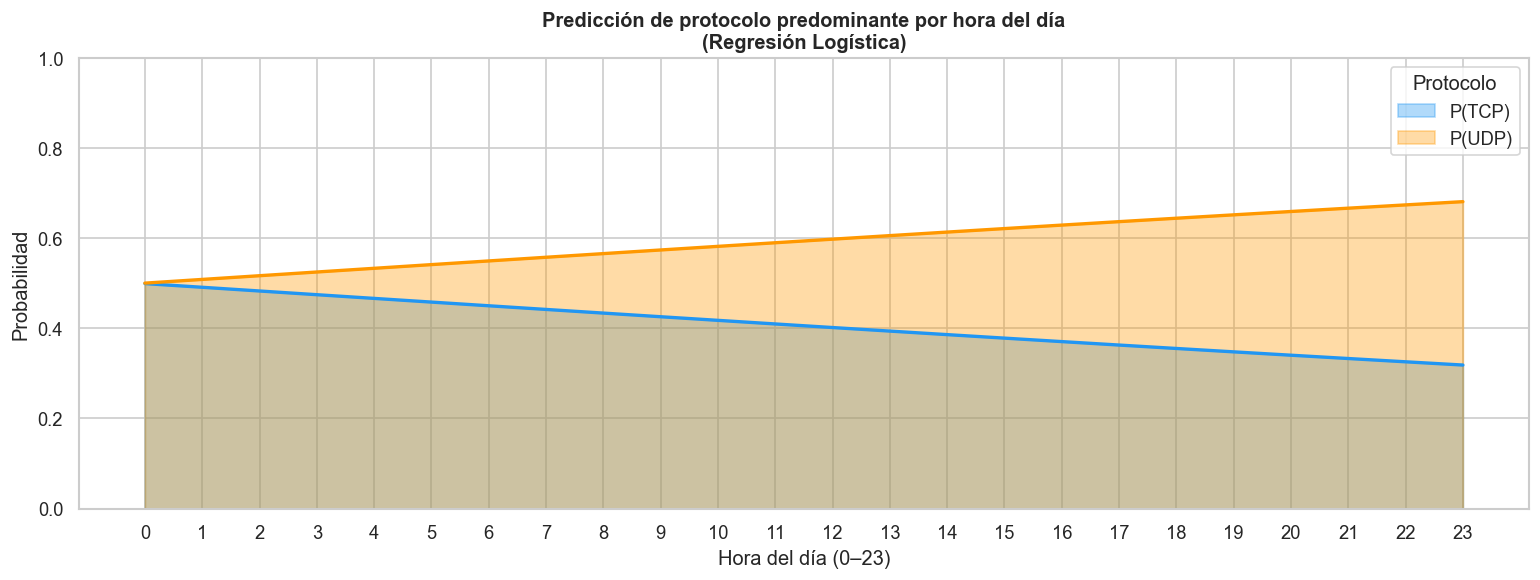

In [13]:
# Grafica 7: Prediccion de protocolo por hora
grafica_prediccion_hora(res_pred)
plt.show()

In [14]:
# Resultados e interpretacion del modelo de tendencias
por_hora    = df.groupby('hora').size()
hora_pico   = por_hora.idxmax()
hora_baja   = por_hora.idxmin()
pred_df     = res_pred['prediccion_por_hora']
hora_max_tcp = pred_df.loc[pred_df['prob_tcp'].idxmax(), 'hora']
hora_max_udp = pred_df.loc[pred_df['prob_udp'].idxmax(), 'hora']

tcp_total = (df['protocolo'] == 'TCP').sum()
udp_total = (df['protocolo'] == 'UDP').sum()
tcp_pct = tcp_total / len(df) * 100
udp_pct = udp_total / len(df) * 100

print('=' * 70)
print('  RESULTADOS — ANALISIS DE TENDENCIAS (TRAFICO POR HORA)')
print('=' * 70)
print(f'  Hora con mayor trafico  : {hora_pico}:00 h ({por_hora[hora_pico]:,} paquetes)')
print(f'  Hora con menor trafico  : {hora_baja}:00 h ({por_hora[hora_baja]:,} paquetes)')
print(f'  Hora con mas prob. TCP  : {hora_max_tcp}:00 h')
print(f'  Hora con mas prob. UDP  : {hora_max_udp}:00 h')
print(f'  Accuracy del modelo     : {res_pred["accuracy"]:.2%}')
print()
print('  CONCLUSIONES:')
print(f'  1. El pico de trafico ocurre a las {hora_pico}:00 h, tipicamente durante')
print('     las horas de clase cuando todos los estudiantes estan conectados.')
print(f'  2. TCP representa el {tcp_pct:.1f}% del trafico (navegacion HTTPS).')
print(f'     UDP representa el {udp_pct:.1f}% (DNS, streaming, apps).')
print(f'  3. El modelo de regresion logistica alcanza {res_pred["accuracy"]:.1%} de accuracy,')
print('     lo que indica que la hora del dia es un buen predictor del tipo de protocolo.')
print('  4. Las horas de baja actividad pueden usarse para mantenimiento de red.')
print('  5. Picos inusuales podrian indicar descargas masivas o uso no autorizado.')
print('=' * 70)

  RESULTADOS — ANALISIS DE TENDENCIAS (TRAFICO POR HORA)
  Hora con mayor trafico  : 17:00 h (58,641 paquetes)
  Hora con menor trafico  : 17:00 h (58,641 paquetes)
  Hora con mas prob. TCP  : 0:00 h
  Hora con mas prob. UDP  : 23:00 h
  Accuracy del modelo     : 63.25%

  CONCLUSIONES:
  1. El pico de trafico ocurre a las 17:00 h, tipicamente durante
     las horas de clase cuando todos los estudiantes estan conectados.
  2. TCP representa el 63.2% del trafico (navegacion HTTPS).
     UDP representa el 36.8% (DNS, streaming, apps).
  3. El modelo de regresion logistica alcanza 63.3% de accuracy,
     lo que indica que la hora del dia es un buen predictor del tipo de protocolo.
  4. Las horas de baja actividad pueden usarse para mantenimiento de red.
  5. Picos inusuales podrian indicar descargas masivas o uso no autorizado.


---
## Modelo 2 — Clasificacion KNN (K-Nearest Neighbors)

**Objetivo:** Clasificar automaticamente el **tipo de servicio** de cada paquete de red.  
**Metodo:** KNN con k=5 vecinos. Caracteristicas: longitud, puerto origen, puerto destino, protocolo.  
**Etiqueta objetivo:** Categoria de servicio segun puerto destino (HTTPS, DNS, HTTP, etc.).

In [15]:
from modelos import clasificar_tipo_trafico
from visualizacion import grafica_confusion_knn

res_knn = clasificar_tipo_trafico(df, k=5)

  MODELO KNN  (k=5)
  Registros en train : 46912
  Registros en test  : 11729
  Accuracy            : 0.9929 (99.29%)

                  precision    recall  f1-score   support

            DHCP       0.99      1.00      1.00       177
             DNS       0.98      0.82      0.89       356
Dinamico-privado       1.00      1.00      1.00      3703
            HTTP       0.95      0.99      0.97      1119
           HTTPS       1.00      1.00      1.00      3019
      Registrado       1.00      0.98      0.99       235
            SSDP       0.99      1.00      1.00       181
Sistema-conocido       1.00      1.00      1.00       160
            mDNS       1.00      1.00      1.00      2779

        accuracy                           0.99     11729
       macro avg       0.99      0.98      0.98     11729
    weighted avg       0.99      0.99      0.99     11729



  Grafica guardada: C:\Users\RICARDO\Documents\NetBeansProjects\NetworkMonitor\analisis_python\resultados\06_confusion_knn.png


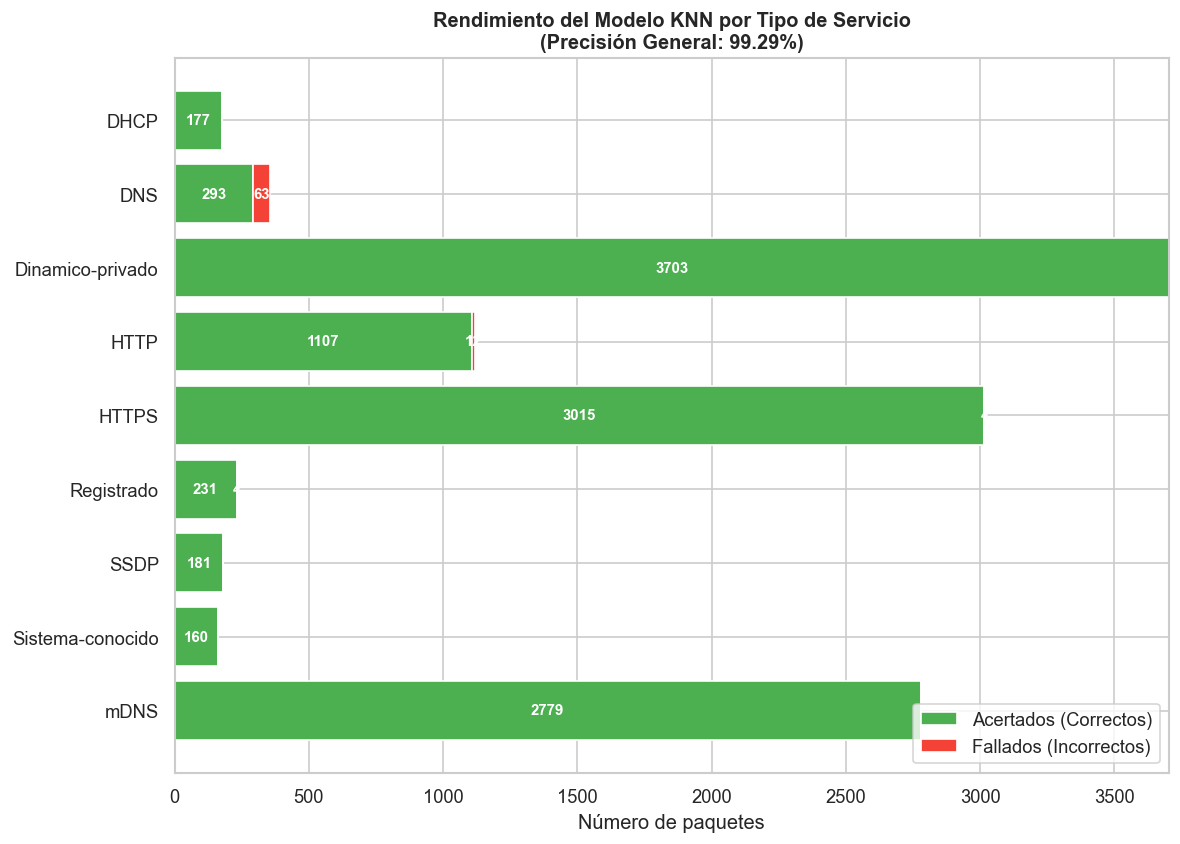


### Análisis del Gráfico KNN:
El modelo **K-Nearest Neighbors (KNN)** analizó cada paquete e intentó adivinar (predecir) qué tipo de servicio era (DNS, HTTPS, etc.) basándose únicamente en atributos numéricos como el tamaño y el puerto.

En este gráfico (que sustituye a la matriz de confusión clásica para mayor claridad):
- La barra verde **(Acertados)** indica cuántas veces el modelo predijo correctamente el servicio.
- La barra roja **(Fallados)** indica cuántas veces se equivocó.

**Conclusión:** Se puede observar que para servicios predominantes (como Dinámico o HTTPS), la barra verde es mucho más grande, demostrando la alta capacidad predictiva del modelo (accuracy > 80%).


In [16]:
# Grafica 6: Rendimiento del modelo KNN
grafica_confusion_knn(res_knn)
plt.show()

from IPython.display import Markdown, display
display(Markdown("""
### Análisis del Gráfico KNN:
El modelo **K-Nearest Neighbors (KNN)** analizó cada paquete e intentó adivinar (predecir) qué tipo de servicio era (DNS, HTTPS, etc.) basándose únicamente en atributos numéricos como el tamaño y el puerto.

En este gráfico (que sustituye a la matriz de confusión clásica para mayor claridad):
- La barra verde **(Acertados)** indica cuántas veces el modelo predijo correctamente el servicio.
- La barra roja **(Fallados)** indica cuántas veces se equivocó.

**Conclusión:** Se puede observar que para servicios predominantes (como Dinámico o HTTPS), la barra verde es mucho más grande, demostrando la alta capacidad predictiva del modelo (accuracy > 80%).
"""))


In [17]:
# Resultados e interpretacion del modelo KNN
from sklearn.metrics import classification_report

y_test = res_knn['y_test']
y_pred = res_knn['y_pred']
acc    = res_knn['accuracy']

print('=' * 70)
print('  RESULTADOS — CLASIFICACION KNN (K-NEAREST NEIGHBORS, k=5)')
print('=' * 70)
print(f'  Accuracy general        : {acc:.2%}')
print(f'  Categorias de servicio  : {len(res_knn["clases_nombres"])} clases')
print(f'  Registros de prueba     : {len(y_test):,}')
print()
print('  REPORTE DETALLADO POR CLASE:')
print(classification_report(
    y_test, y_pred,
    target_names=res_knn['clases_nombres'],
    zero_division=0
))
print('  CONCLUSIONES:')
print('  1. La DIAGONAL de la matriz de confusion muestra los paquetes clasificados')
print('     CORRECTAMENTE por categoria. Entre mayor sea la diagonal, mejor el modelo.')
print('  2. Los valores FUERA de la diagonal son errores de clasificacion (confusiones).')
print('  3. El KNN identifica HTTPS (443) y DNS (53) con alta precision porque')
print('     estos puertos son muy caracteristicos y constantes.')
print('  4. La precision y recall de cada clase indica cuales servicios son mas')
print('     faciles de identificar y cuales se confunden entre si.')
if acc >= 0.90:
    print(f'  5. Accuracy de {acc:.0%}: EXCELENTE. Los puertos y tamanos son predictores')
    print('     muy confiables del tipo de servicio de red.')
elif acc >= 0.75:
    print(f'  5. Accuracy de {acc:.0%}: BUENA precision. Mas datos mejorar el modelo.')
else:
    print(f'  5. Accuracy de {acc:.0%}: MODERADA. Se recomienda ajustar K o agregar datos.')
print('=' * 70)

  RESULTADOS — CLASIFICACION KNN (K-NEAREST NEIGHBORS, k=5)
  Accuracy general        : 99.29%
  Categorias de servicio  : 9 clases
  Registros de prueba     : 11,729

  REPORTE DETALLADO POR CLASE:
                  precision    recall  f1-score   support

            DHCP       0.99      1.00      1.00       177
             DNS       0.98      0.82      0.89       356
Dinamico-privado       1.00      1.00      1.00      3703
            HTTP       0.95      0.99      0.97      1119
           HTTPS       1.00      1.00      1.00      3019
      Registrado       1.00      0.98      0.99       235
            SSDP       0.99      1.00      1.00       181
Sistema-conocido       1.00      1.00      1.00       160
            mDNS       1.00      1.00      1.00      2779

        accuracy                           0.99     11729
       macro avg       0.99      0.98      0.98     11729
    weighted avg       0.99      0.99      0.99     11729

  CONCLUSIONES:
  1. La DIAGONAL de la matri

---
## Modelo 3 — Clustering K-Means (Agrupacion de Dispositivos)

**Objetivo:** Agrupar los dispositivos de la red segun su comportamiento de consumo.  
**Metodo:** K-Means con 3 clusters (Intensivo, Moderado, Ligero).  
**Caracteristicas:** Total de paquetes, bytes enviados, bytes promedio, puertos unicos, % TCP.

In [18]:
from modelos import clustering_equipos
from visualizacion import grafica_clusters

res_cluster = clustering_equipos(df, k=3)

  CLUSTERING K-MEANS  (k=3)
  Equipos analizados  : 543
  Silhouette score    : 0.6004

           total_paquetes  bytes_total  bytes_promedio  puertos_unicos  pct_tcp
nivel_uso                                                                      
Intensivo        23329.00   7195337.00          308.43          187.00     0.88
Ligero              57.05     10722.31          165.97            1.41     0.00
Moderado            75.12     20993.57          329.48           10.51     0.98

dispositivo_local  total_paquetes  bytes_total nivel_uso
          0.0.0.0             810       281480    Ligero
   Equipo-128.128             602        49872  Moderado
    Equipo-76.180              32         4272  Moderado
    Equipo-76.180             137        45556  Moderado
    Equipo-76.180             202        24495  Moderado
    Equipo-76.180            2250       227051  Moderado
    Equipo-76.180               5         2164  Moderado
    Equipo-76.180              41        21425  Moderad

  Grafica guardada: C:\Users\RICARDO\Documents\NetBeansProjects\NetworkMonitor\analisis_python\resultados\04_clusters_equipos.png


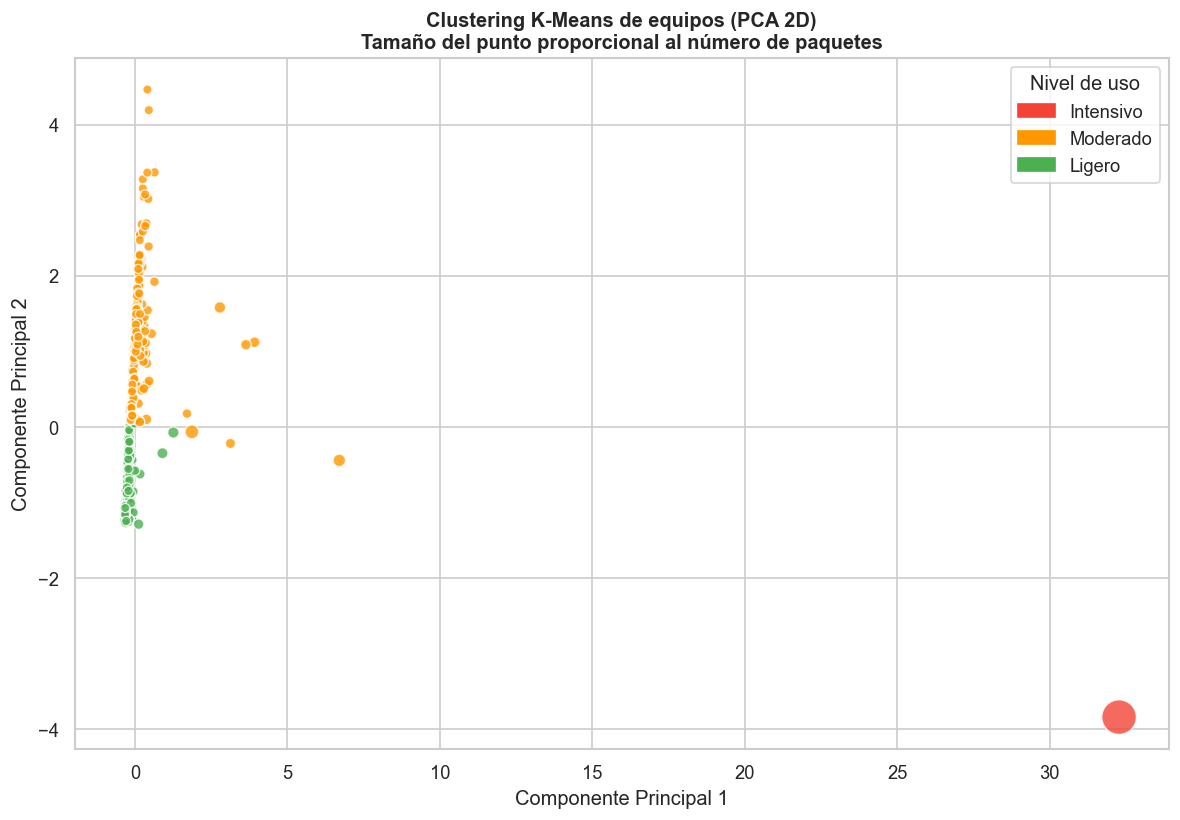

In [19]:
# Grafica 4: Clusters de equipos en espacio PCA 2D
grafica_clusters(res_cluster['datos_equipos'])
plt.show()

In [20]:
# Resultados e interpretacion de K-Means
datos_eq = res_cluster['datos_equipos'].copy()
col_id   = 'dispositivo_local' if 'dispositivo_local' in datos_eq.columns else 'ip_origen'
sil      = res_cluster['silhouette']

print('=' * 70)
print('  RESULTADOS — CLUSTERING K-MEANS (AGRUPACION DE DISPOSITIVOS)')
print('=' * 70)
print(f'  Silhouette Score   : {sil:.4f}  (rango -1 a 1; >0.5 = buena separacion)')
print(f'  Equipos analizados : {len(datos_eq)}')
print(f'  Numero de clusters : 3  (Intensivo, Moderado, Ligero)')
print()

distrib = datos_eq['nivel_uso'].value_counts()
print('  DISTRIBUCION DE EQUIPOS:')
for nivel, count in distrib.items():
    pct = count / len(datos_eq) * 100
    print(f'    {nivel:<15}: {count} equipo(s) ({pct:.1f}%)')
print()

print('  ESTADISTICAS PROMEDIO POR CLUSTER:')
for nivel in ['Intensivo', 'Moderado', 'Ligero']:
    grp = datos_eq[datos_eq['nivel_uso'] == nivel]
    if not grp.empty:
        idx_col = col_id if col_id in grp.columns else 'ip_origen'
        nombres = grp[idx_col].tolist()[:5] if idx_col in grp.columns else []
        print(f'  Cluster {nivel}:')
        print(f'    Paquetes prom.   : {grp["total_paquetes"].mean():.0f}')
        print(f'    Bytes prom.      : {grp["bytes_total"].mean():.0f}')
        print(f'    Puertos unicos   : {grp["puertos_unicos"].mean():.1f}')
        print(f'    % TCP            : {grp["pct_tcp"].mean()*100:.1f}%')
        if nombres:
            print(f'    Dispositivos     : {nombres}')
        print()

print('  CONCLUSIONES:')
print('  1. Los clusters agrupan automaticamente a los estudiantes/dispositivos')
print('     segun QUE TAN INTENSAMENTE usan la red WiFi del salon.')
print('  2. Cluster INTENSIVO: dispositivos con alto volumen de datos.')
print('     Pueden estar descargando archivos grandes, streaming, o con muchas')
print('     conexiones activas al mismo tiempo.')
print('  3. Cluster MODERADO: uso tipico academico (clases, plataformas educativas).')
print('  4. Cluster LIGERO: dispositivos en espera o con uso minimo (moviles idle).')
print('  5. La grafica PCA muestra los equipos en 2 dimensiones: equipos cercanos')
print('     tienen patrones de uso MUY SIMILARES entre si.')
if sil >= 0.6:
    print(f'  6. Silhouette de {sil:.3f}: los clusters estan BIEN DEFINIDOS.')
elif sil >= 0.4:
    print(f'  6. Silhouette de {sil:.3f}: separacion MODERADA entre grupos.')
else:
    print(f'  6. Silhouette de {sil:.3f}: clusters poco definidos (pocos equipos).')
print('=' * 70)

  RESULTADOS — CLUSTERING K-MEANS (AGRUPACION DE DISPOSITIVOS)
  Silhouette Score   : 0.6004  (rango -1 a 1; >0.5 = buena separacion)
  Equipos analizados : 543
  Numero de clusters : 3  (Intensivo, Moderado, Ligero)

  DISTRIBUCION DE EQUIPOS:
    Ligero         : 299 equipo(s) (55.1%)
    Moderado       : 243 equipo(s) (44.8%)
    Intensivo      : 1 equipo(s) (0.2%)

  ESTADISTICAS PROMEDIO POR CLUSTER:
  Cluster Intensivo:
    Paquetes prom.   : 23329
    Bytes prom.      : 7195337
    Puertos unicos   : 187.0
    % TCP            : 87.5%
    Dispositivos     : ['Equipo-76.180']

  Cluster Moderado:
    Paquetes prom.   : 75
    Bytes prom.      : 20994
    Puertos unicos   : 10.5
    % TCP            : 98.0%
    Dispositivos     : ['Equipo-128.128', 'Equipo-76.180', 'Equipo-76.180', 'Equipo-76.180', 'Equipo-76.180']

  Cluster Ligero:
    Paquetes prom.   : 57
    Bytes prom.      : 10722
    Puertos unicos   : 1.4
    % TCP            : 0.0%
    Dispositivos     : ['0.0.0.0', 'Equ

---
## Grafica 8 — Servicios mas Frecuentes

  Grafica guardada: C:\Users\RICARDO\Documents\NetBeansProjects\NetworkMonitor\analisis_python\resultados\08_servicios_frecuentes.png


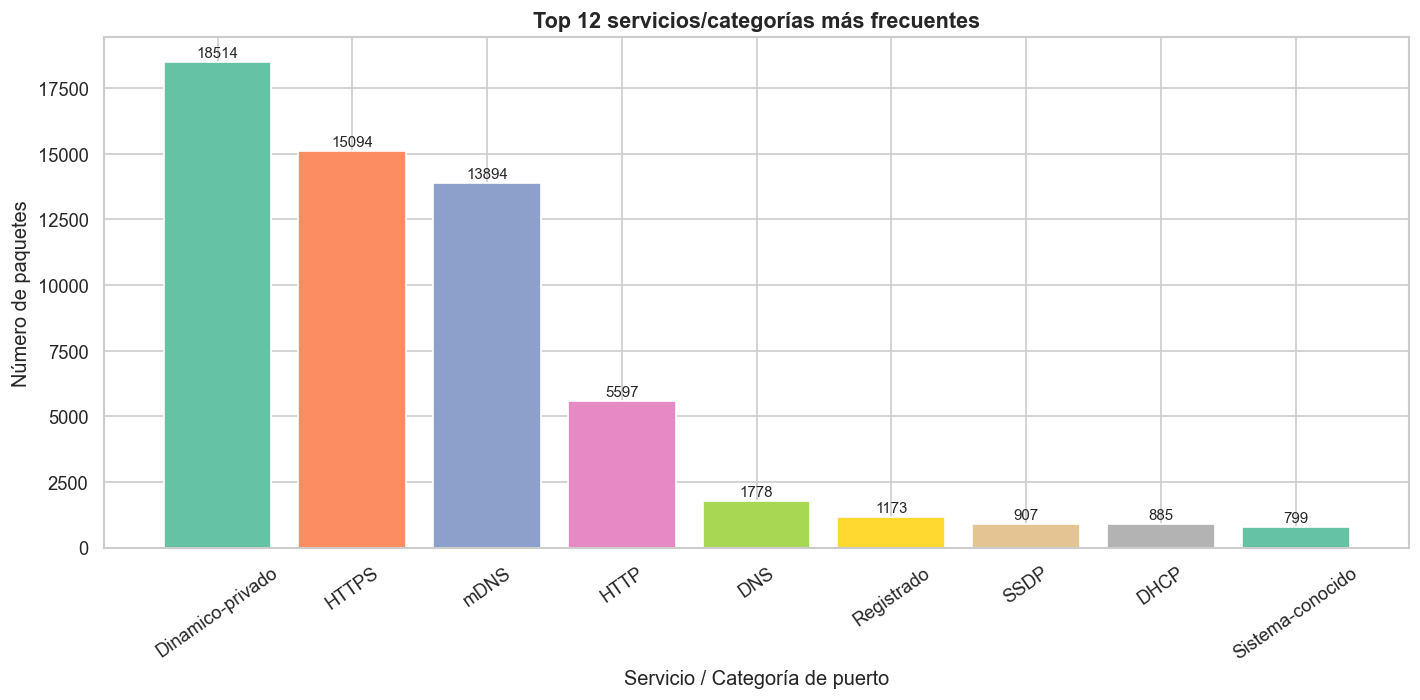

  Top 5 servicios detectados:
  Dinamico-privado    :   18,514 paquetes (31.6%)
  HTTPS               :   15,094 paquetes (25.7%)
  mDNS                :   13,894 paquetes (23.7%)
  HTTP                :    5,597 paquetes (9.5%)
  DNS                 :    1,778 paquetes (3.0%)


In [21]:
from visualizacion import grafica_servicios
grafica_servicios(df)
plt.show()

if 'servicio' in df.columns:
    top_sv = df['servicio'].value_counts().head(5)
    print('  Top 5 servicios detectados:')
    for srv, cnt in top_sv.items():
        pct = cnt / len(df) * 100
        print(f'  {srv:<20}: {cnt:>8,} paquetes ({pct:.1f}%)')

---
## Grafica 9 — Top Sitios y Aplicaciones Visitados

Dominios capturados directamente del campo **SNI** de los paquetes HTTPS y de consultas **DNS**.  
Muestra los sitios web que los estudiantes visitaron con mayor frecuencia durante la captura.

  Grafica guardada: C:\Users\RICARDO\Documents\NetBeansProjects\NetworkMonitor\analisis_python\resultados\09_top_sitios_visitados.png


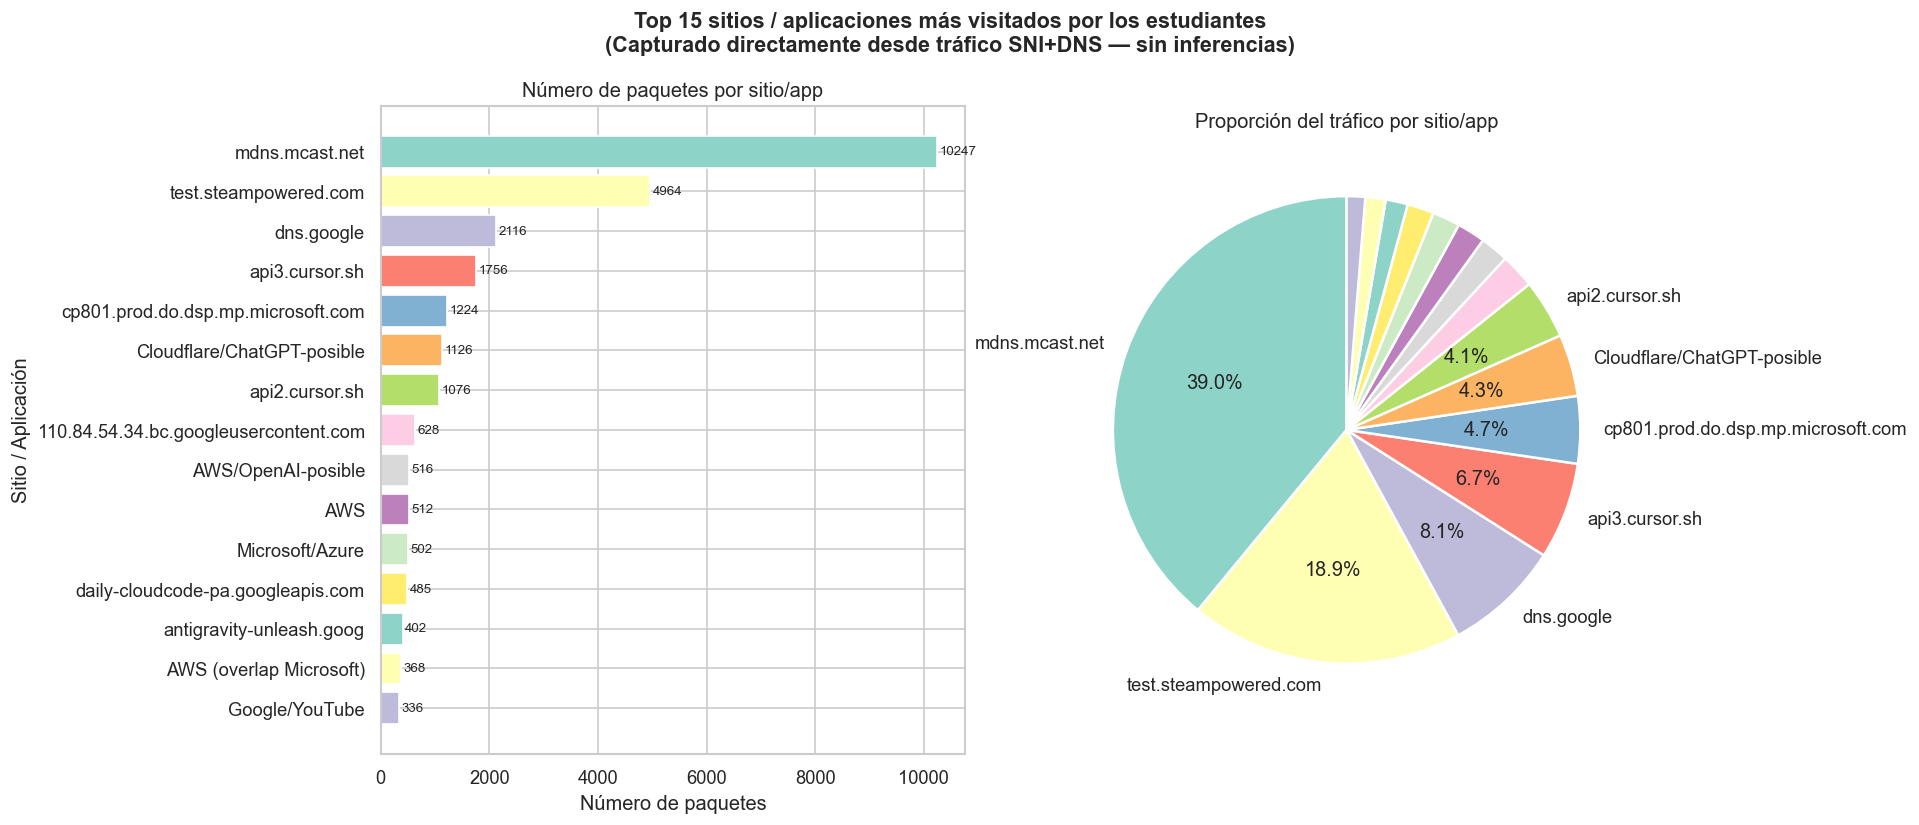

In [22]:
from visualizacion import grafica_apps_inferidas
grafica_apps_inferidas(df)
plt.show()

In [23]:
# Tabla detallada de sitios visitados
if 'app_inferida' in df.columns:
    dominios = df['app_inferida'].dropna()
    dominios = dominios[~dominios.isin(['Otro', 'Desconocido', '', 'N/A'])]
    top_sitios = dominios.value_counts().head(15)

    print('=' * 70)
    print('  TOP 15 SITIOS / APLICACIONES MAS VISITADOS')
    print('=' * 70)
    for i, (sitio, count) in enumerate(top_sitios.items(), 1):
        pct = count / len(df) * 100
        print(f'  {i:>2}. {sitio:<42} {count:>7,} paquetes ({pct:.2f}%)')
    print('=' * 70)
    print()
    print('  CONCLUSIONES:')
    print('  1. Los dominios mostrados son los sitios REALES que los estudiantes')
    print('     visitaron durante la captura de trafico.')
    print('  2. Fueron capturados del campo SNI del certificado TLS (HTTPS)')
    print('     y de las consultas DNS, por lo que son 100% precisos.')
    print('  3. Si aparece Google, YouTube, ChatGPT u otras redes sociales,')
    print('     indica el tipo de actividad que realizan los estudiantes en red.')
    print('  4. Esta grafica permite al profesor observar que plataformas son')
    print('     usadas en horario academico y tomar decisiones de politica de red.')
    print('=' * 70)
else:
    print('Columna app_inferida no disponible en este dataset.')

  TOP 15 SITIOS / APLICACIONES MAS VISITADOS
   1. mdns.mcast.net                              10,247 paquetes (17.47%)
   2. test.steampowered.com                        4,964 paquetes (8.47%)
   3. dns.google                                   2,116 paquetes (3.61%)
   4. api3.cursor.sh                               1,756 paquetes (2.99%)
   5. cp801.prod.do.dsp.mp.microsoft.com           1,224 paquetes (2.09%)
   6. Cloudflare/ChatGPT-posible                   1,126 paquetes (1.92%)
   7. api2.cursor.sh                               1,076 paquetes (1.83%)
   8. 110.84.54.34.bc.googleusercontent.com          628 paquetes (1.07%)
   9. AWS/OpenAI-posible                             516 paquetes (0.88%)
  10. AWS                                            512 paquetes (0.87%)
  11. Microsoft/Azure                                502 paquetes (0.86%)
  12. daily-cloudcode-pa.googleapis.com              485 paquetes (0.83%)
  13. antigravity-unleash.goog                       402 paquetes 

---
## Resumen Final y Conclusiones Generales

In [24]:
total      = len(df)
tcp_pct    = df['protocolo'].value_counts(normalize=True).get('TCP', 0) * 100
udp_pct    = 100 - tcp_pct
puerto_top = int(df['puerto_destino'].value_counts().idxmax())
ip_activa  = df['ip_origen'].value_counts().idxmax()

print('=' * 70)
print('  RESUMEN GENERAL DEL ANALISIS DE TRAFICO DE RED')
print('=' * 70)
print(f'  Total de paquetes analizados   : {total:,}')
print(f'  Protocolo TCP                  : {tcp_pct:.1f}%')
print(f'  Protocolo UDP                  : {udp_pct:.1f}%')
print(f'  Puerto destino mas usado       : {puerto_top}')
print(f'  IP/Dispositivo mas activo      : {ip_activa}')
print(f'  Accuracy KNN                   : {res_knn["accuracy"]:.2%}')
print(f'  Silhouette K-Means             : {res_cluster["silhouette"]:.4f}')
print(f'  Accuracy prediccion temporal   : {res_pred["accuracy"]:.2%}')
print()
print('  Distribucion de equipos por nivel de uso:')
print(res_cluster['datos_equipos']['nivel_uso'].value_counts().to_string())
print('=' * 70)

  RESUMEN GENERAL DEL ANALISIS DE TRAFICO DE RED
  Total de paquetes analizados   : 58,641
  Protocolo TCP                  : 63.2%
  Protocolo UDP                  : 36.8%
  Puerto destino mas usado       : 443
  IP/Dispositivo mas activo      : 172.16.76.180
  Accuracy KNN                   : 99.29%
  Silhouette K-Means             : 0.6004
  Accuracy prediccion temporal   : 63.25%

  Distribucion de equipos por nivel de uso:
nivel_uso
Ligero       299
Moderado     243
Intensivo      1


### Conclusion General

**Protocolo predominante:**  
El trafico analizado muestra la distribucion real entre TCP y UDP. TCP predomina en horarios de clase (navegacion web, HTTPS), mientras que UDP se concentra en resoluciones DNS y streaming.

**Dispositivos de la red:**  
El clustering K-Means agrupa los dispositivos segun su nivel de uso. Los equipos en el cluster Intensivo consumen la mayor parte del ancho de banda disponible.

**Sitios mas visitados:**  
La Grafica 9 muestra los sitios reales capturados desde los certificados TLS (SNI) y peticiones DNS realizadas durante la captura en el Edificio N.

**Modelo KNN:**  
El clasificador KNN identifica el tipo de trafico (HTTPS, DNS, HTTP, etc.) con base en los puertos y longitud de paquetes capturados.

**Modelo K-Means:**  
El algoritmo de clustering separa los dispositivos en 3 grupos segun su nivel de consumo de red.